# **Benchmark Notebook**

```bash
!git clone --depth=1 https://github.com/lof310/transformer
%cd transformer

# Install dependencies
!pip install -r requirements.txt

# Install on developer mode (Recommended)
!pip install -e .
```

## **Imports**

In [1]:
import math
import os
import random
import urllib.request
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import wandb
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

from transformer import Transformer, TransformerBlock, TransformerConfig

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams["figure.dpi"] = 120

torch.set_num_threads(6)

## **Data**

In [2]:
class CharTokenizer:
    def __init__(self, text):
        chars = sorted(list(set(text)))
        self.stoi = {ch: i for i, ch in enumerate(chars)}
        self.itos = {i: ch for i, ch in enumerate(chars)}

    @property
    def vocab_size(self):
        return len(self.stoi)

    def encode(self, text):
        return [self.stoi[ch] for ch in text]

    def decode(self, ids):
        return ''.join([self.itos[i] for i in ids])

class BinDataset(Dataset):
    def __init__(self, data_array, block_size: int, stride: int = 64):
        self.data = torch.as_tensor(data_array, dtype=torch.long)
        self.block_size = block_size
        self.stride = stride

    def __len__(self) -> int:
        return max(0, (len(self.data) - self.block_size) // self.stride + 1)

    def __getitem__(self, idx: int):
        start = idx * self.stride
        end = start + self.block_size
        x = self.data[start:end]
        y = self.data[start+1:end+1]
        return {"input_ids": x, "labels": y, "k": 8}

def prepare_data(block_size=64, split_ratio=0.985):
    if not os.path.exists('input.txt'):
        url = 'https://gutenberg.org/ebooks/2600.txt.utf-8'
        urllib.request.urlretrieve(url, 'input.txt')

    with open('input.txt', 'r') as f:
        text = f.read()

    tokenizer = CharTokenizer(text)
    ids = tokenizer.encode(text)
    train_size = int(split_ratio * len(ids))
    train_ids, val_ids = ids[:train_size], ids[train_size:]
    train_ds = BinDataset(train_ids, block_size)
    val_ds = BinDataset(val_ids, block_size)
    return tokenizer, train_ds, val_ds

## **Definitions**

In [17]:
class TransformerDecoderBlock(TransformerBlock):
    def __init__(
        self,
        config,
        attn_kwargs: Optional[Dict] = {},
        ffn_kwargs: Optional[Dict] = {},
        norm_kwargs: Optional[Dict] = {},
        layer_idx: int = 0,
    ):
        super().__init__(config, attn_kwargs, ffn_kwargs, norm_kwargs, layer_idx)

        self.eps = 1e-8

        self.alpha_attn, self.alpha_ffn = (
            nn.Parameter(torch.empty(1, 1, config.d_model)),
            nn.Parameter(torch.empty(1, 1, config.d_model))
        )

        self.beta_attn, self.beta_ffn = (
            nn.Parameter(torch.empty(1, 1, config.d_model)),
            nn.Parameter(torch.empty(1, 1, config.d_model))
        )

        nn.init.normal_(self.alpha_attn, mean=0.25, std=0.50)
        nn.init.normal_(self.alpha_ffn, mean=0.25, std=0.50)
        nn.init.normal_(self.beta_attn, mean=0.15, std=0.25)
        nn.init.normal_(self.beta_ffn, mean=0.15, std=0.25)

    def forward(
        self,
        x: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        pos: Optional[torch.Tensor] = None,
        flash_attn: Tuple[
            bool,
            Union[list[torch.nn.attention.SDPBackend], torch.nn.attention.SDPBackend],
            bool,
        ] = (
            False,
            torch.nn.attention.SDPBackend.FLASH_ATTENTION,
            False,
        ),
        return_states: Optional[bool] = False,
    ) -> Union[torch.Tensor, Dict]:

        def extract(out):
            """Helper to extract output tensor from module return (handles dict vs tensor)"""
            return out["output"] if return_states else out

        def _update(x, y, alpha, beta):
            norm_y = torch.sum(y, dim=-1, keepdim=True)
            num = (x * y).sum(dim=-1, keepdim=True)
            denom = (x * x).sum(dim=-1, keepdim=True).clamp_min(self.eps)
            proj = num / denom
            parallel = beta * proj * (y / norm_y)
            orth = alpha * (y - proj * x)
            return x + orth + parallel

        attn = self.attn(
            self.norm_attn(x),
            return_states=return_states,
            **{"mask": attn_mask, "pos": pos, "flash_attn": flash_attn},
        )
        
        x = _update(x, extract(attn), self.alpha_attn, self.beta_attn)
        ffn = self.ffn(self.norm_ffn(x), return_states=return_states)
        x = _update(x, extract(ffn), self.alpha_ffn, self.beta_ffn)

        if return_states:
            return {"output": x, "attn_output": attn, "ffn_output": ffn}
        else:
            return x

## **Setup**

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
block_size = 128
n_layers = 5
n_heads = 8
d_model = 256
batch_size = 12
max_steps = 3500
eval_interval = 100

learning_rate = 6e-5
weight_decay = 1e-2

tokenizer, train_ds, val_ds = prepare_data(block_size)
vocab_size = tokenizer.vocab_size

torch.manual_seed(123)
torch.cuda.manual_seed(123)
torch.cuda.manual_seed_all(123)

models = {
    "New Update": Transformer(
        TransformerConfig(
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            vocab_size=vocab_size,
            seq_len=block_size,
            max_seq_len=block_size*8,
            attn_qk_norm=False,
            block_class=TransformerDecoderBlock,
        )
    ),
    "Baseline": Transformer(
        TransformerConfig(
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            vocab_size=vocab_size,
            seq_len=block_size,
            max_seq_len=block_size*8,
            attn_qk_norm=False,
        )
    )
}

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

## **Training**

In [ ]:
def compute_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=-1)
    return (preds == labels).float().mean().item()

def train_model(model, optimizer, scheduler, max_steps=2000, eval_interval=199):
    model = model.to(device)

    metrics = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "grad_norm": [], "generation_speed": []
    }
    step = 0
    epoch = 0
    best_val_loss = float('inf')

    pbar = tqdm(total=max_steps, desc="Training ..")
    while step < max_steps:
        for batch in train_loader:
            if step >= max_steps:
                break

            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, labels=labels, flash_attn=(True, torch.nn.attention.SDPBackend.FLASH_ATTENTION, False))
            loss = outputs.loss

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            metrics["train_loss"].append(loss.item())
            metrics["train_acc"].append(compute_accuracy(outputs.logits.view(-1, vocab_size), labels.view(-1)))
            metrics["grad_norm"].append(grad_norm.item())

            if step % 5:
                pbar.set_postfix(
                    {
                        "train_loss": f"{loss.item():.4f}",
                        "val_loss": f"{(metrics["val_loss"][-1]):.4f}",
                        "train_acc": f"{metrics["train_acc"][-1]:.4f}",
                        "val_acc": f"{metrics["val_acc"][-1]:.4f}",
                        "grad_norm": f"{grad_norm.item():.2f}",
                    }
                )
            
            if step % eval_interval == 0 or step == max_steps - 1:
                model.eval()
                with torch.no_grad():
                    train_acc = compute_accuracy(outputs.logits.view(-1, vocab_size), labels.view(-1))

                    val_losses, val_accs = [], []
                    for val_batch in val_loader:
                        val_input_ids = val_batch["input_ids"].to(device)
                        val_labels = val_batch["labels"].to(device)
                        val_outputs = model(val_input_ids, labels=val_labels)
                        val_losses.append(val_outputs.loss.item())
                        val_accs.append(compute_accuracy(
                            val_outputs.logits.view(-1, vocab_size),
                            val_labels.view(-1)
                        ))

                    avg_val_loss = np.mean(val_losses)
                    avg_val_acc = np.mean(val_accs)

                    metrics["val_loss"].append(avg_val_loss)
                    metrics["val_acc"].append(avg_val_acc)

                    if avg_val_loss < best_val_loss:
                        best_val_loss = avg_val_loss

                model.train()
                pbar.set_postfix(
                    {
                        "train_loss": f"{loss.item():.4f}",
                        "val_loss": f"{avg_val_loss:.4f}",
                        "train_acc": f"{train_acc:.4f}",
                        "val_acc": f"{avg_val_acc:.4f}",
                        "grad_norm": f"{grad_norm.item():.2f}",
                    }
                )

            step += 1
            pbar.update(1)
        epoch += 1

    pbar.close()
    return metrics

all_metrics = {}
for name, model in models.items():
    print(f"Training {name}...")
    wandb.init(
        project="Residual Stream",
        name="Benchmark Residual Stream",
        notes="Run for uploading results to my research-experiments repo",
        config={
            "training_config": {
                "device": device,
                "block_size": block_size,
                "batch_size": batch_size,
                "max_steps": max_steps,
                "eval_interval": eval_interval,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay
            },
            "baseline_config": models["Baseline"].config
        },
        job_type="benchmark",
        mode="offline",
        anonymous="allow",
        save_code=True
    )
    wandb.watch(model, log="gradients", log_freq=250, idx=0 if name == "New Update" else 1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_steps)
    metrics = train_model(model, optimizer, scheduler, max_steps, eval_interval)
    all_metrics[name] = metrics

Training New Update...


Training ..:   0%|          | 0/3500 [00:00<?, ?it/s]

## **Plots**

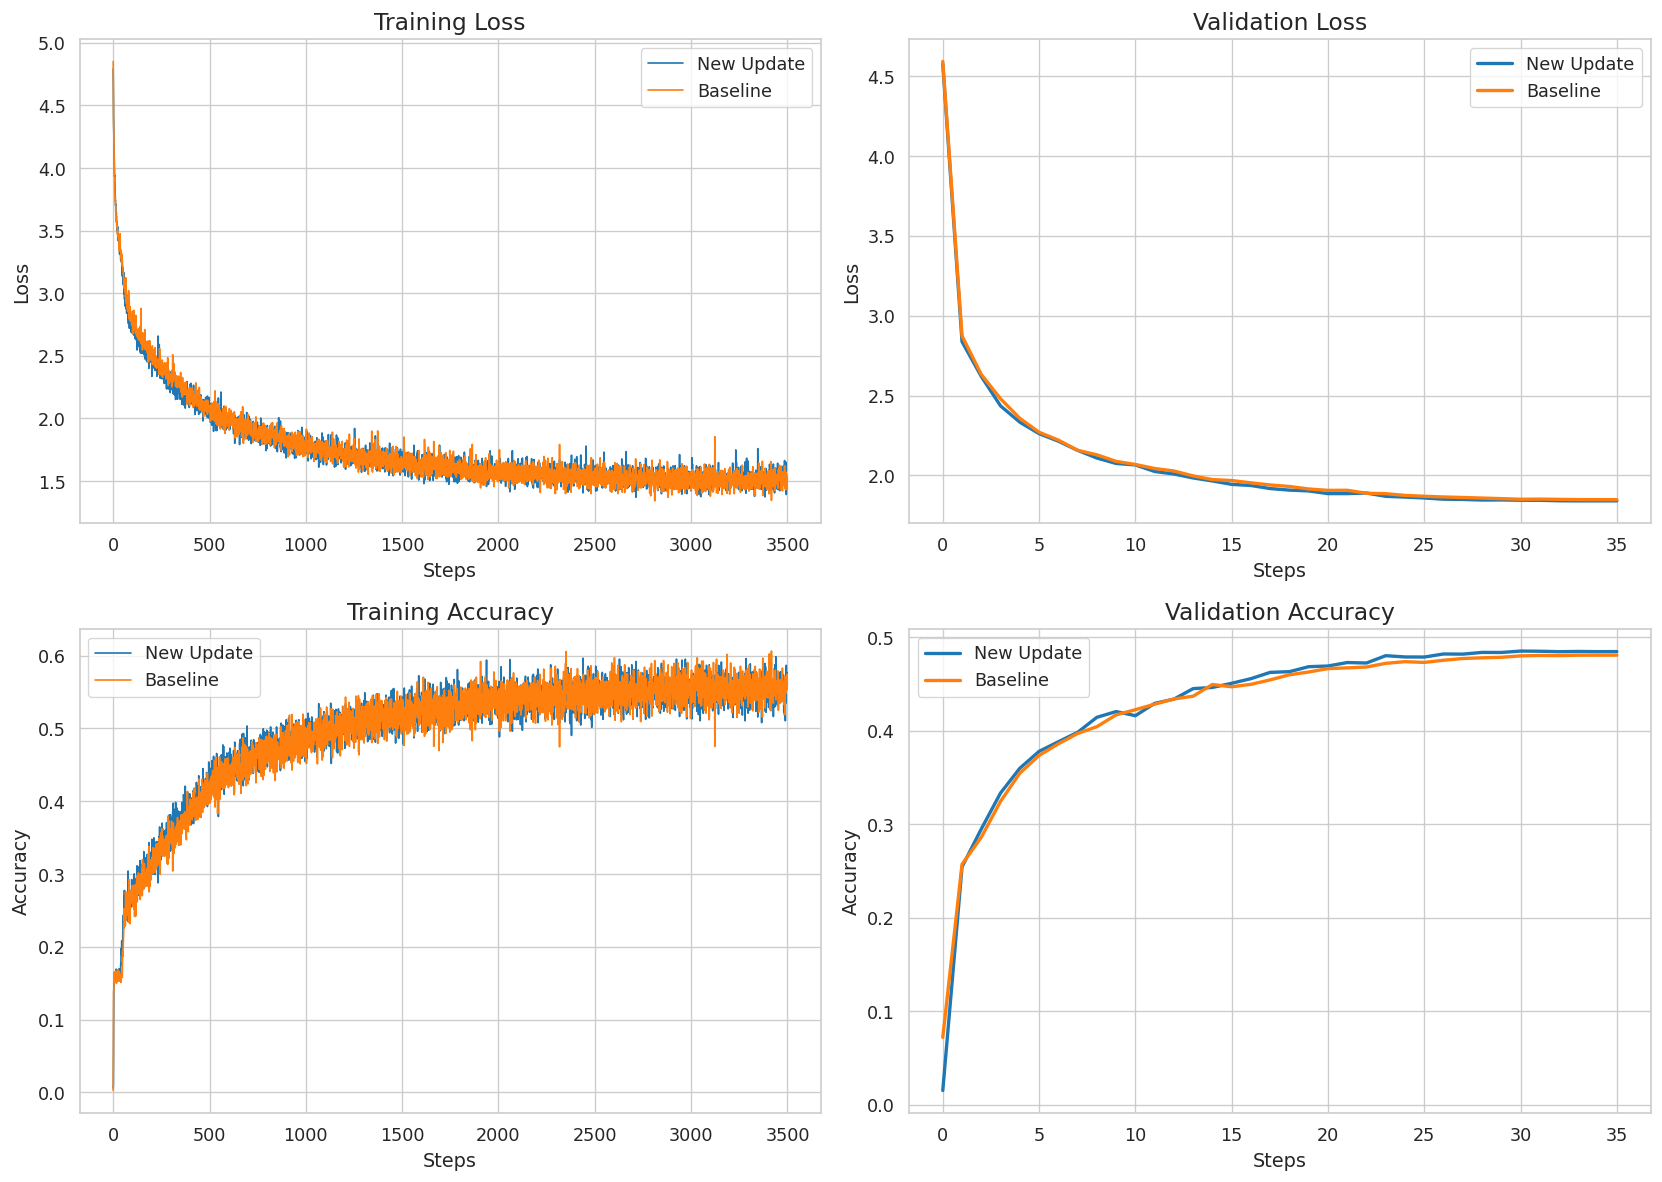

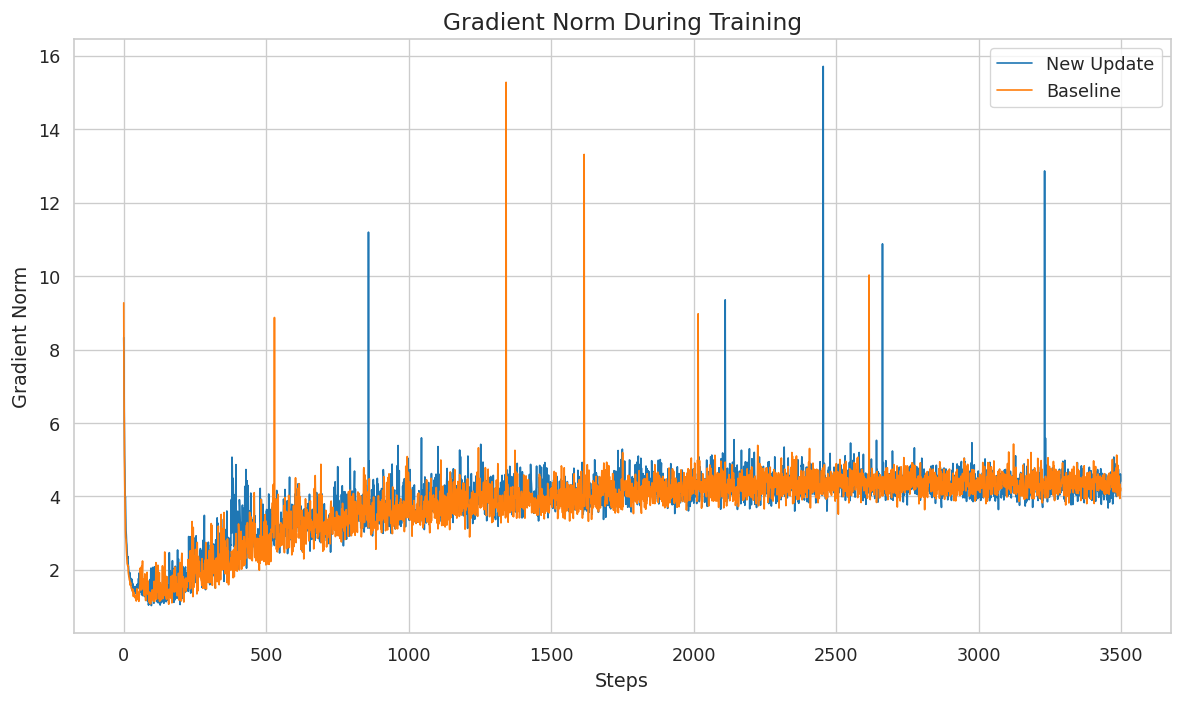

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for name, metrics in all_metrics.items():
    wandb.log({
        "train_loss": metrics["train_loss"],
        "val_loss": metrics["val_loss"],
        "train_acc": metrics["train_acc"],
        "val_acc": metrics["val_acc"],
        "grad_norm": metrics["grad_norm"]
    })

# Plot training loss
for name, metrics in all_metrics.items():
    axs[0, 0].plot(metrics["train_loss"], label=name, linewidth=1)
axs[0, 0].set_title('Training Loss', fontsize=14)
axs[0, 0].set_xlabel('Steps')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()

# Plot validation loss
for name, metrics in all_metrics.items():
    axs[0, 1].plot(metrics["val_loss"], label=name, linewidth=2)
axs[0, 1].set_title('Validation Loss', fontsize=14)
axs[0, 1].set_xlabel('Steps')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()

# Plot training accuracy
for name, metrics in all_metrics.items():
    axs[1, 0].plot(metrics["train_acc"], label=name, linewidth=1)
axs[1, 0].set_title('Training Accuracy', fontsize=14)
axs[1, 0].set_xlabel('Steps')
axs[1, 0].set_ylabel('Accuracy')
axs[1, 0].legend()

# Plot validation accuracy
for name, metrics in all_metrics.items():
    axs[1, 1].plot(metrics["val_acc"], label=name, linewidth=2)
axs[1, 1].set_title('Validation Accuracy', fontsize=14)
axs[1, 1].set_xlabel('Steps')
axs[1, 1].set_ylabel('Accuracy')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('plots/Residual Stream/model_benchmark_loss_acc.png', bbox_inches='tight', dpi=200)
plt.show()

# Plot gradient norms
plt.figure(figsize=(10, 6))
for name, metrics in all_metrics.items():
    plt.plot(metrics["grad_norm"], label=name, linewidth=1)
plt.title('Gradient Norm During Training', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Gradient Norm')
plt.legend()
plt.tight_layout()
plt.savefig('plots/Residual Stream/model_benchmark_grad_norm.png', bbox_inches='tight', dpi=200)
plt.show()

# **Generation**

In [10]:
@torch.no_grad
def generate(model, input_ids, tokenizer, max_new_tokens=32):
    generated = input_ids
    for i in range(max_new_tokens):
        out = model(input_ids=generated).logits[:, -1, :]
        out = torch.argmax(out, dim=-1, keepdims=True)
        generated = torch.cat([generated, out], dim=-1)
        print(tokenizer.itos[int(generated.squeeze(0)[-1])], end='', flush=True)

In [12]:
prompt = "War and Peace"
for name, model in models.items():
    print(f"\nGenerating with {name}:")
    print(f"\n{prompt}", end='')
    generate(model, torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0), tokenizer, max_new_tokens=128)


Generating with New Update:

War and Peaced the same the same and the same the same and the same and the same and the same the same and the same the same and the same the
Generating with Baseline:

War and Peace and something and the same of the same of the same of the same of the same of the same of the same of the same of the same of t

## **Analysis**

New Update Model:
  Best Val Loss: 1.8406 at step 33
  Worst Val Loss: 4.5771 at step 0
  Best Val Acc: 0.4851 at step 30
  Worst Val Acc: 0.0151 at step 0
  Best Train Loss: 1.3706 at step 2713
  Worst Train Loss: 4.7907 at step 0
  Best Train Acc: 0.5983 at step 3440
  Worst Train Acc: 0.0059 at step 0
  Mean Val Loss: 2.0829 ± 0.4873
  Mean Train Loss: 1.7555 ± 0.3737
  Mean Val Acc: 0.4283 ± 0.0907
  Mean Train Acc: 0.4968 ± 0.0820
  Grad Norm: max=15.7124, min=1.0296, mean=3.8580 ± 0.9152
  Last Val Loss: 1.8409, Last Train Loss: 1.5132, Last Val Acc: 0.4846, Last Train Acc: 0.5612

Baseline Model:
  Best Val Loss: 1.8483 at step 35
  Worst Val Loss: 4.5932 at step 0
  Best Val Acc: 0.4807 at step 35
  Worst Val Acc: 0.0720 at step 0
  Best Train Loss: 1.3414 at step 2811
  Worst Train Loss: 4.8510 at step 0
  Best Train Acc: 0.6061 at step 3417
  Worst Train Acc: 0.0026 at step 0
  Mean Val Loss: 2.0971 ± 0.4898
  Mean Train Loss: 1.7617 ± 0.3882
  Mean Val Acc: 0.4258 ± 0.0828
 

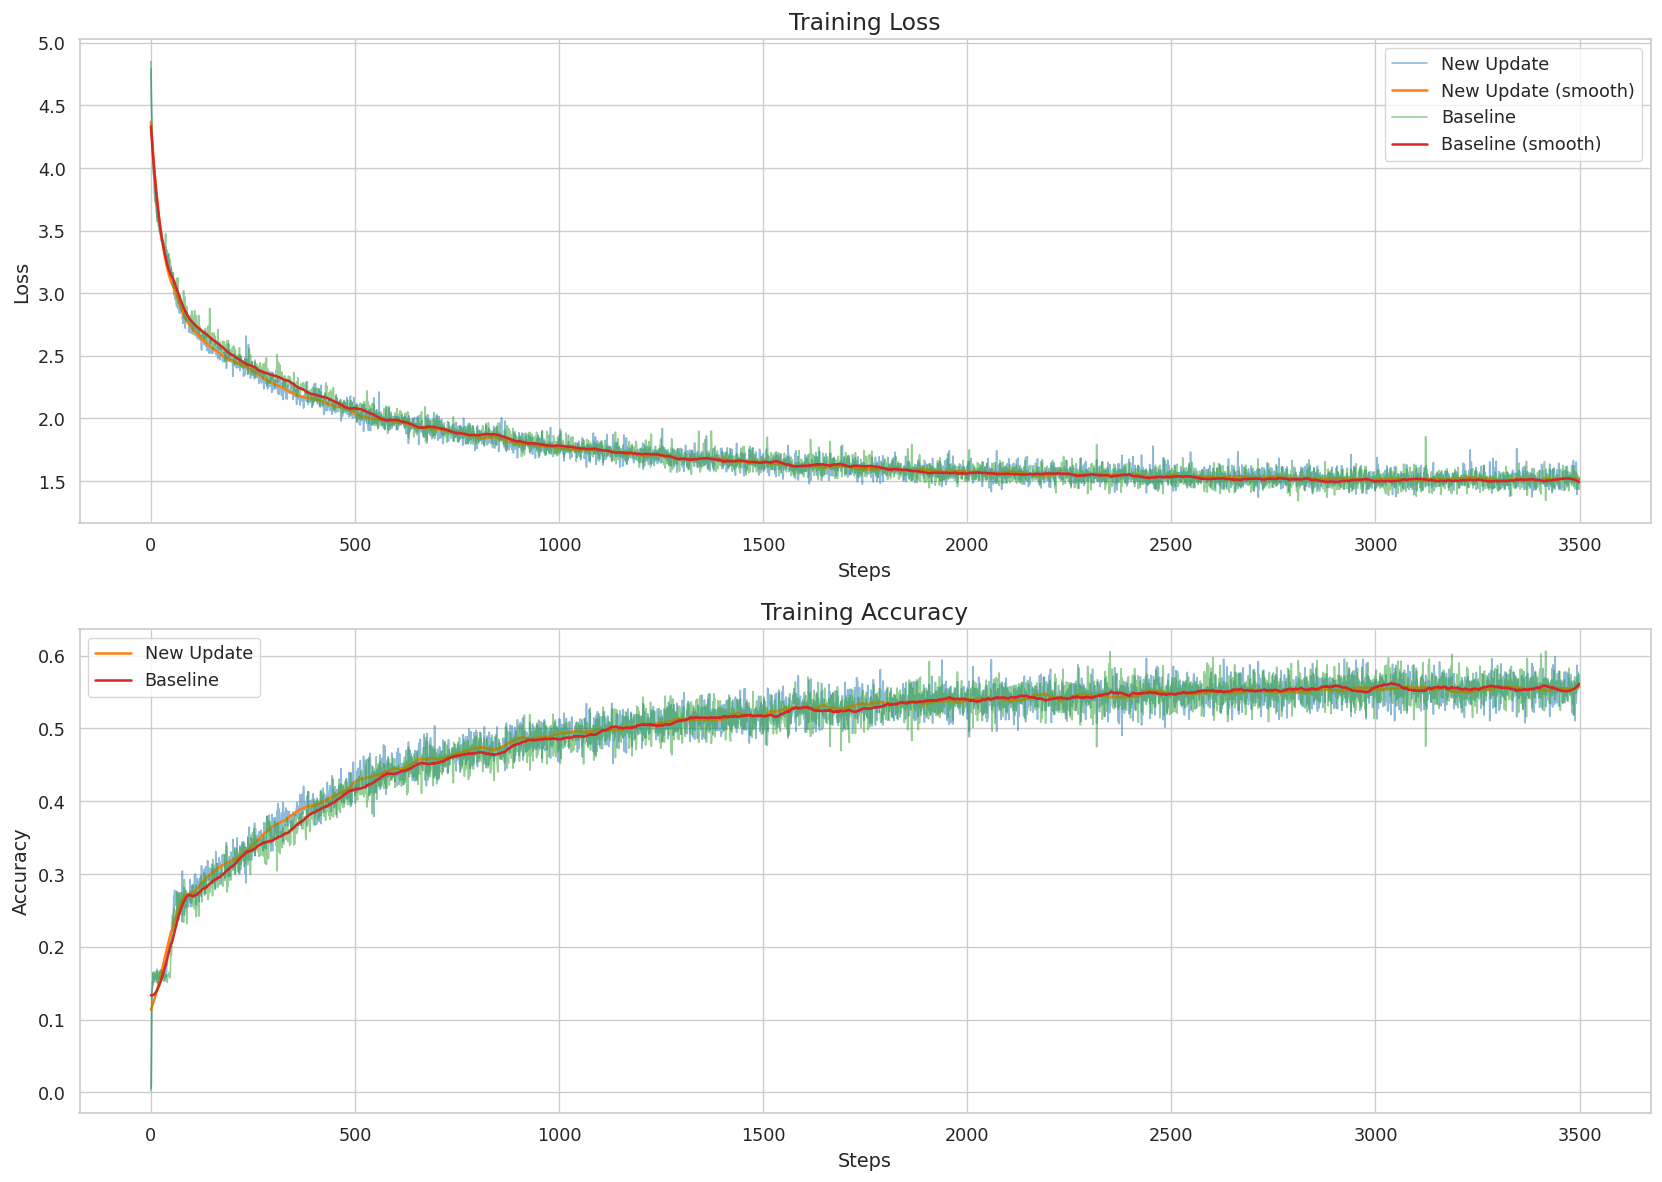

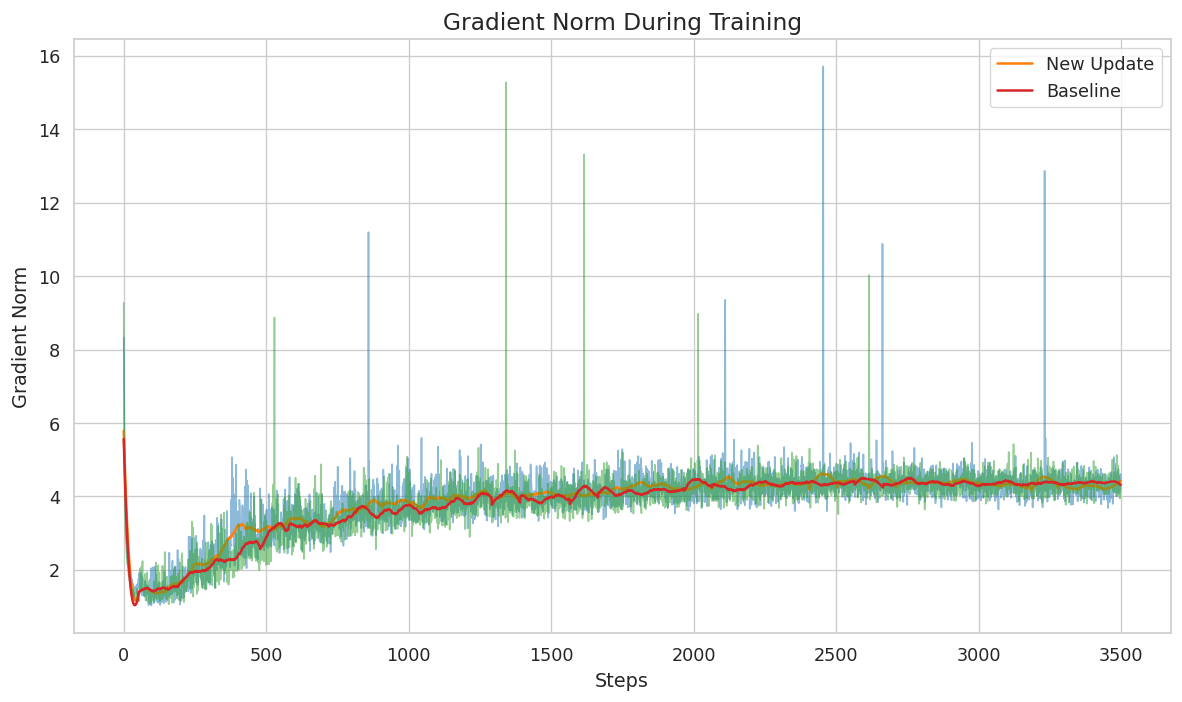

In [13]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# --- Statistics ---
for name, metrics in all_metrics.items():
    train_loss = torch.tensor(metrics["train_loss"])
    val_loss = torch.tensor(metrics["val_loss"])
    train_acc = torch.tensor(metrics["train_acc"])
    val_acc = torch.tensor(metrics["val_acc"])
    grad_norm = torch.tensor(metrics["grad_norm"])

    best_val_loss = val_loss.min(dim=-1)
    worst_val_loss = val_loss.max(dim=-1)
    best_val_acc = val_acc.max(dim=-1)
    worst_val_acc = val_acc.min(dim=-1)
    best_train_loss = train_loss.min(dim=-1)
    worst_train_loss = train_loss.max(dim=-1)
    best_train_acc = train_acc.max(dim=-1)
    worst_train_acc = train_acc.min(dim=-1)

    print(f"{name} Model:")
    print(f"  Best Val Loss: {best_val_loss.values:.4f} at step {best_val_loss.indices}")
    print(f"  Worst Val Loss: {worst_val_loss.values:.4f} at step {worst_val_loss.indices}")
    print(f"  Best Val Acc: {best_val_acc.values:.4f} at step {best_val_acc.indices}")
    print(f"  Worst Val Acc: {worst_val_acc.values:.4f} at step {worst_val_acc.indices}")
    print(f"  Best Train Loss: {best_train_loss.values:.4f} at step {best_train_loss.indices}")
    print(f"  Worst Train Loss: {worst_train_loss.values:.4f} at step {worst_train_loss.indices}")
    print(f"  Best Train Acc: {best_train_acc.values:.4f} at step {best_train_acc.indices}")
    print(f"  Worst Train Acc: {worst_train_acc.values:.4f} at step {worst_train_acc.indices}")
    print(f"  Mean Val Loss: {val_loss.mean():.4f} ± {val_loss.std():.4f}")
    print(f"  Mean Train Loss: {train_loss.mean():.4f} ± {train_loss.std():.4f}")
    print(f"  Mean Val Acc: {val_acc.mean():.4f} ± {val_acc.std():.4f}")
    print(f"  Mean Train Acc: {train_acc.mean():.4f} ± {train_acc.std():.4f}")
    print(f"  Grad Norm: max={grad_norm.max():.4f}, min={grad_norm.min():.4f}, mean={grad_norm.mean():.4f} ± {grad_norm.std():.4f}")
    print(f"  Last Val Loss: {val_loss[-1]:.4f}, Last Train Loss: {train_loss[-1]:.4f}, Last Val Acc: {val_acc[-1]:.4f}, Last Train Acc: {train_acc[-1]:.4f}\n")

# --- Plots with smoothing ---
fig, axs = plt.subplots(2, 1, figsize=(14, 10))
window = 100
polyorder = 3

for name, metrics in all_metrics.items():
    train_loss = metrics["train_loss"]
    val_loss = metrics["val_loss"]
    train_acc = metrics["train_acc"]
    val_acc = metrics["val_acc"]

    if len(train_loss) >= window:
        train_loss_smooth = savgol_filter(train_loss, window, polyorder)
        train_acc_smooth = savgol_filter(train_acc, window, polyorder)
    else:
        train_loss_smooth = train_loss
        train_acc_smooth = train_acc

    axs[0].plot(torch.arange(len(train_loss)), train_loss, label=name, linewidth=1.0, alpha=0.5)
    axs[0].plot(torch.arange(len(train_loss)), train_loss_smooth, label=f"{name} (smooth)", linewidth=1.5)
    axs[1].plot(torch.arange(len(train_acc)), train_acc, linewidth=1.0, alpha=0.5)
    axs[1].plot(torch.arange(len(train_acc)), train_acc_smooth, label=name, linewidth=1.5)

axs[0].set_title('Training Loss', fontsize=14)
axs[0].set_xlabel('Steps')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[1].set_title('Training Accuracy', fontsize=14)
axs[1].set_xlabel('Steps')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.legend()
plt.savefig('plots/Residual Stream/model_benchmark_loss_acc_smooth.png', bbox_inches='tight', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
for name, metrics in all_metrics.items():
    grad = metrics["grad_norm"]
    plt.plot(grad, linewidth=1.0, alpha=0.5)
    if len(grad) >= window:
        grad_smooth = savgol_filter(grad, window, polyorder)
        plt.plot(grad_smooth, label=name, linewidth=1.5)
    else:
        plt.plot(grad, label=name, linewidth=1.5)
plt.title('Gradient Norm During Training', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Gradient Norm')
plt.legend()
plt.tight_layout()
plt.savefig('plots/Residual Stream/model_benchmark_grad_norm_smooth.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
prompt = "First Citizen:\nFirst, you know Caius Marcius is enemy to the people. so this is the enemy and a text sample from the dataset"

x = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)
B, N = x.shape
attn_mask, pos = torch.triu(torch.ones(N, N, device=x.device), diagonal=1).bool(), torch.arange(N, device=x.device)
blocks_output = {}

with torch.no_grad():
    for name, model in models.items():
        input_emb = model.emb(x)
        
        model.eval()
        blocks_output.setdefault(name, [])
    
        emb = model.emb
        blocks = model.blocks
        norm_out = model.norm_out
        lm_head = model.lm_head
        output = input_emb

        for block in blocks:
            out = block(output, attn_mask, pos, return_states=True)
            output = out["output"]
            blocks_output[name].append(out)

New Update Parameters: 2694492M
Baseline Parameters: 2689372M


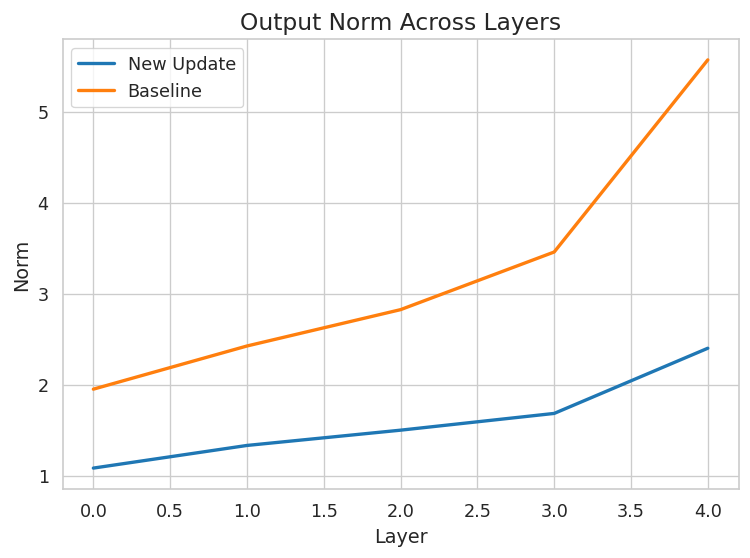

In [15]:
# ===== Model Parameters =====
for name, model in models.items():
    print(f"{name} Parameters: {model.get_num_params()}M")

# ===== Output Norm Across Layers =====
for name, outputs in blocks_output.items():
    output_norm = []
    for i in range(models[name].config.n_layer):
        output_norm.append(outputs[i]["output"].norm(dim=-1).mean().detach())
        
    plt.plot(output_norm, label=name, linewidth=2)

plt.title("Output Norm Across Layers", fontsize=14)
plt.xlabel("Layer")
plt.ylabel("Norm")
plt.legend()
plt.tight_layout()
plt.savefig("plots/Residual Stream/norm_across_layers.png", dpi=200)
plt.show()

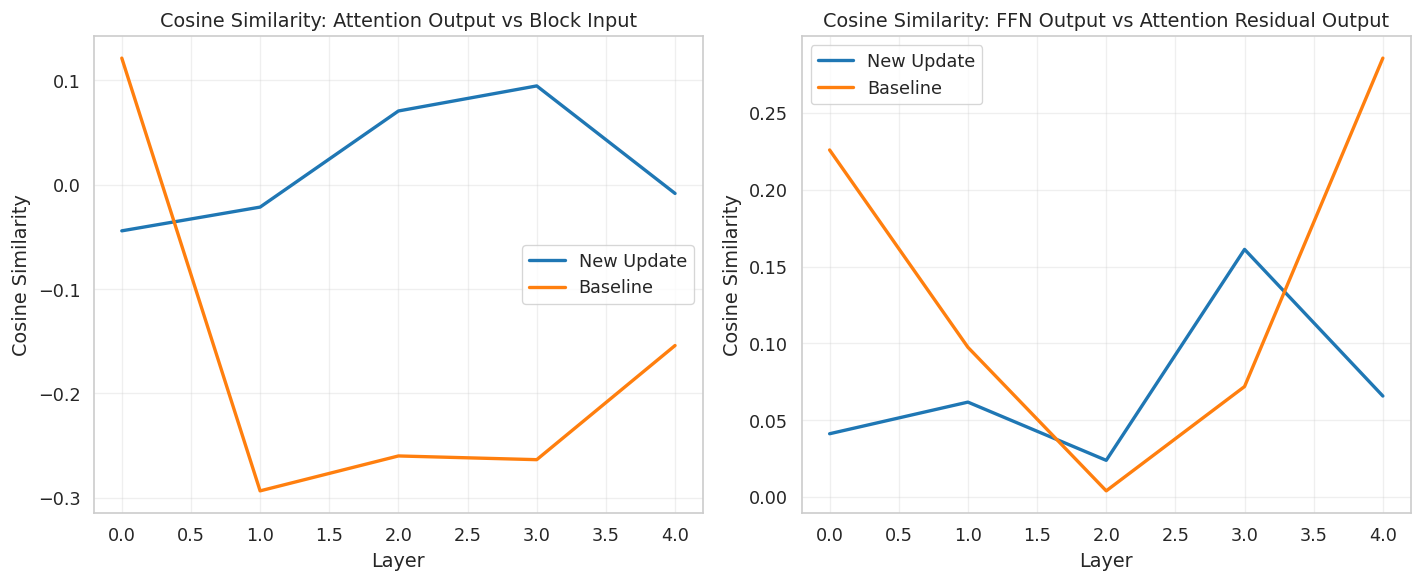


=== Final Layer Statistics (after final norm) ===
New Update: mean=-0.0967, std=1.0425, min=-4.9010, max=3.6772
Baseline: mean=0.0103, std=1.0511, min=-3.6234, max=3.7721


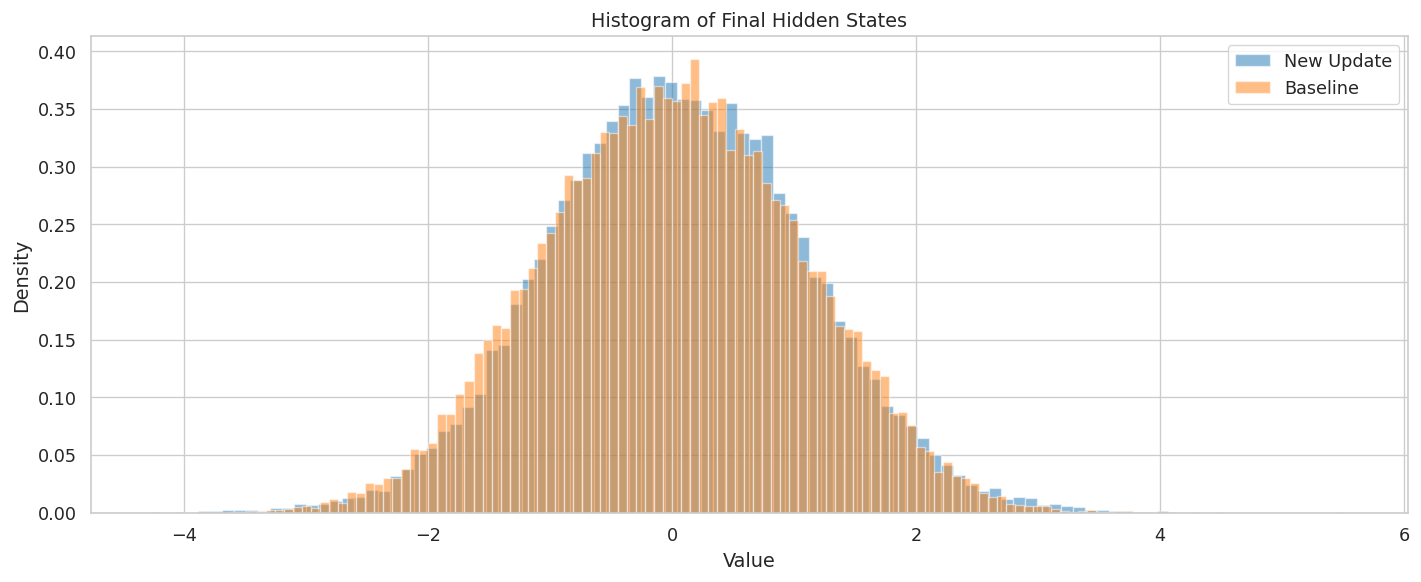

In [16]:
import torch.nn.functional as F

# Store results per model
cos_attn_per_layer = {}
cos_ffn_per_layer = {}
final_stats = {}

for name, model in models.items():
    with torch.no_grad():
        input_emb = model.emb(x)
        output = input_emb

        block_inputs = []
        attn_outputs = []
        ffn_outputs = []

        for block in model.blocks:
            block_input = output
            out = block(block_input, attn_mask, pos, return_states=True)
            attn_out = out["attn_output"]["output"]
            ffn_out = out["ffn_output"]["output"]

            block_inputs.append(block_input)
            attn_outputs.append(attn_out)
            ffn_outputs.append(ffn_out)

            # compute residual outputs for next layer
            attn_residual = block_input + attn_out
            block_output = attn_residual + ffn_out
            output = block_output

        final_hidden = model.norm_out(output)        # (B, N, D)
        logits = model.lm_head(final_hidden)         # (B, N, vocab_size)

        # Per-layer cosine similarities
        cos_attn = []
        cos_ffn = []
        for i in range(len(block_inputs)):
            bi = block_inputs[i].reshape(-1, model.config.d_model)
            ao = attn_outputs[i].reshape(-1, model.config.d_model)
            fo = ffn_outputs[i].reshape(-1, model.config.d_model)
            attn_res = (block_inputs[i] + attn_outputs[i]).reshape(-1, model.config.d_model)

            cos_attn.append(F.cosine_similarity(bi, ao, dim=-1).mean().item())
            cos_ffn.append(F.cosine_similarity(attn_res, fo, dim=-1).mean().item())

        cos_attn_per_layer[name] = cos_attn
        cos_ffn_per_layer[name] = cos_ffn

        # Final layer statistics (after final norm)
        stats = {
            "mean": final_hidden.mean().item(),
            "std": final_hidden.std().item(),
            "min": final_hidden.min().item(),
            "max": final_hidden.max().item(),
        }
        final_stats[name] = stats

# ===== Plot Cosine Similarities =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for name, cos_vals in cos_attn_per_layer.items():
    plt.plot(cos_vals, label=name, linewidth=2)
plt.title("Cosine Similarity: Attention Output vs Block Input")
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, cos_vals in cos_ffn_per_layer.items():
    plt.plot(cos_vals, label=name, linewidth=2)
plt.title("Cosine Similarity: FFN Output vs Attention Residual Output")
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/Residual Stream/cosine_similarities.png", dpi=200)
plt.show()

# ===== Final Layer Statistics =====
print("\n=== Final Layer Statistics (after final norm) ===")
for name, stats in final_stats.items():
    print(f"{name}: mean={stats['mean']:.4f}, std={stats['std']:.4f}, min={stats['min']:.4f}, max={stats['max']:.4f}")
    
plt.figure(figsize=(12, 5))
for name, model in models.items():
    with torch.no_grad():
        input_emb = model.emb(x)
        output = input_emb
        for block in model.blocks:
            output = block(output, attn_mask, pos, return_states=False)
        final_hidden = model.norm_out(output)
        plt.hist(final_hidden.flatten().cpu().numpy(), bins=100, alpha=0.5, label=name, density=True)
plt.title("Histogram of Final Hidden States")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("plots/Residual Stream/final_hidden_histogram.png", dpi=200)
plt.show()

In [ ]:
!systemctl hibernate